# Random Forest :

In [1]:
import pandas as pd
df=pd.read_csv("titanic.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [2]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [3]:
df['Age']=df['Age'].fillna(df['Age'].median())

In [4]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
import numpy as np
df['Sex']=np.where(df['Sex']=='male',1,0)  # df['Sex']=df['Sex'].map({'female':0,'male':1})

In [6]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,S


In [7]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [8]:
x=df[ ['Pclass','Sex','Age', 'SibSp','Parch', 'Fare'] ]
y=df['Survived']
print(x.shape)
print(y.shape)

(891, 6)
(891,)


In [9]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(712, 6)
(712,)
(179, 6)
(179,)


In [10]:
from sklearn.ensemble import RandomForestClassifier
rf= RandomForestClassifier( criterion='entropy', n_estimators=100,random_state=1 )
model = rf.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(y_pred)

[1 0 1 0 1 0 0 1 0 1 0 0 0 0 1 1 0 0 0 1 1 0 1 0 1 0 1 1 0 1 0 1 1 0 0 0 1
 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 1 0 1 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 1 0 0 1 0 0 1
 0 0 0 0 0 0 0 1 0 1 1 0 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0 0 1 1 0 1 0 0 0 0 0
 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 1 0 1 0 1 0 1 0 1 0 0 0 1]


In [11]:
from sklearn.metrics import confusion_matrix,accuracy_score
cm=confusion_matrix(y_test,y_pred)
print(cm)
print()
print("Accuracy score: ",accuracy_score(y_test,y_pred))

[[96 10]
 [28 45]]

Accuracy score:  0.7877094972067039


In [12]:
sample = x_test.iloc[0:1]
print(sample)
prediction=model.predict(sample)
print(prediction)

     Pclass  Sex   Age  SibSp  Parch     Fare
862       1    0  48.0      0      0  25.9292
[1]


In [13]:
# As dictionary :
sample_dict=sample.iloc[0].to_dict()
print(f"Sample Passenger: {sample_dict}")
print(f"Predicted Survival: {'Survived' if prediction[0]==1 else 'Not Survived'}")

Sample Passenger: {'Pclass': 1.0, 'Sex': 0.0, 'Age': 48.0, 'SibSp': 0.0, 'Parch': 0.0, 'Fare': 25.9292}
Predicted Survival: Survived


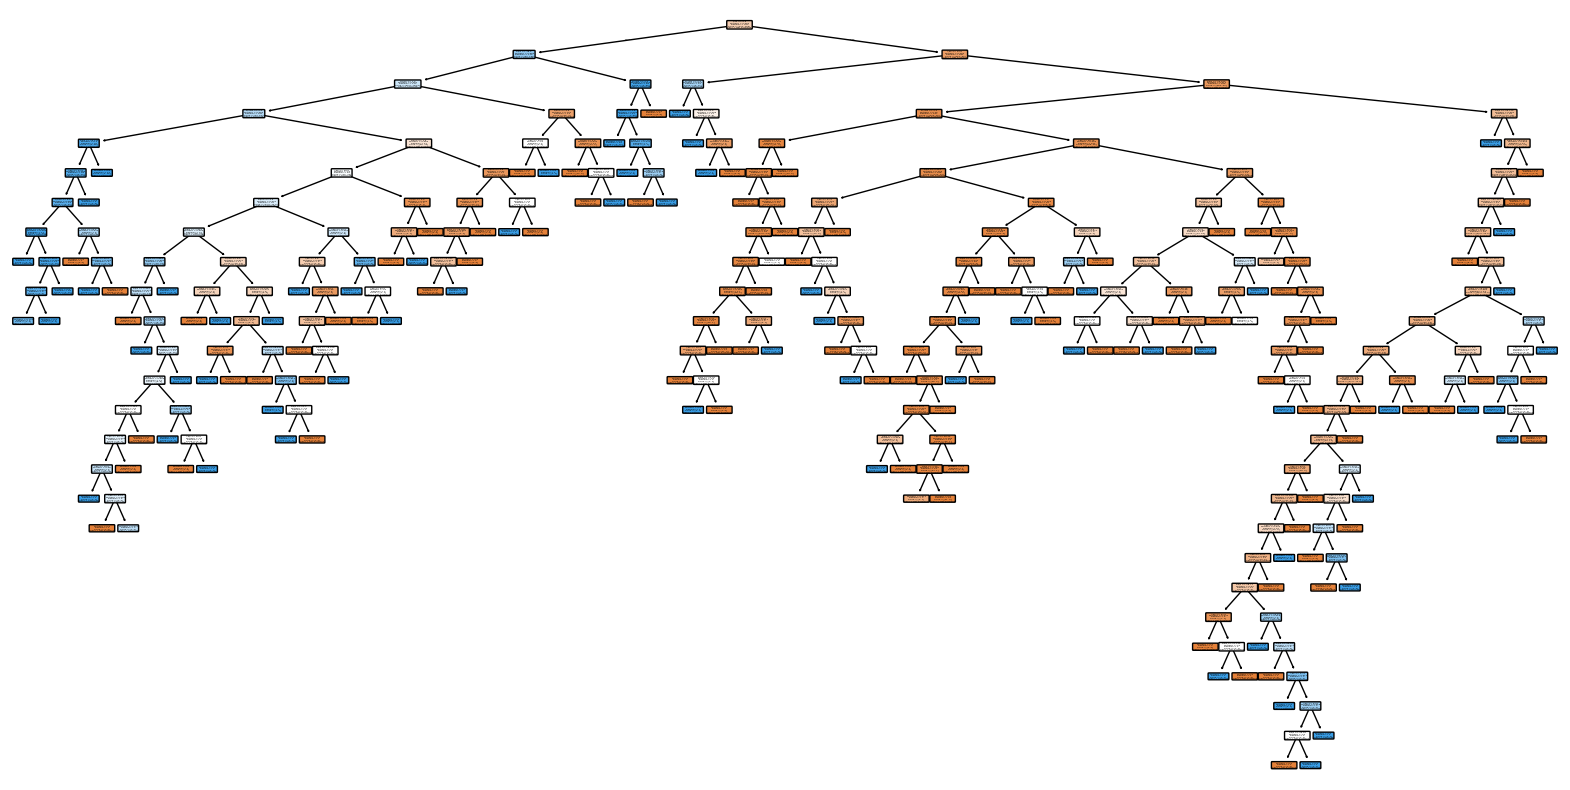

In [14]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
choose_tree=model.estimators_[0]
plt.figure(figsize=(20,10))

plot_tree(choose_tree,
         feature_names=['Pclass','Sex','Age', 'SibSp','Parch', 'Fare'],
         class_names=['Not Survived','Survived'],
         filled=True,
         rounded=True)
plt.show()

* Example :

In [15]:
data={'Weight':[150,170,140,180,160,155],
    'Textarea':['Smooth','Rough','Smooth','Rough','Smooth','Rough'],
     'Color':['red','orange','green','orange','red','yellow'],
     'Fruit':['Apple','Orange','Apple','Orange','Apple','Orange']
     } 
df=pd.DataFrame(data)
df

,Weight,Textarea,Color,Fruit
0,150,Smooth,red,Apple
1,170,Rough,orange,Orange
2,140,Smooth,green,Apple
3,180,Rough,orange,Orange
4,160,Smooth,red,Apple
5,155,Rough,yellow,Orange


In [16]:
import numpy as np
df['Textarea']=np.where(df['Textarea']=='Smooth',0,1)
df['Color']=np.where(df['Color']=="red",0,np.where(df['Color']=='orange',1,np.where(df['Color']=='green',2,3)))
df

,Weight,Textarea,Color,Fruit
0,150,0,0,Apple
1,170,1,1,Orange
2,140,0,2,Apple
3,180,1,1,Orange
4,160,0,0,Apple
5,155,1,3,Orange


In [17]:
x=df.iloc[:,0:3]
y=df.iloc[:,-1]
print(x.shape)
print(y.shape)

(6, 3)
(6,)


In [18]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(4, 3)
(4,)
(2, 3)
(2,)


In [19]:
from sklearn.ensemble import RandomForestClassifier
rf= RandomForestClassifier( criterion='entropy', n_estimators=10,random_state=1 )
model = rf.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(y_pred)

['Apple' 'Orange']


In [20]:
from sklearn.metrics import confusion_matrix,accuracy_score
cm=confusion_matrix(y_test,y_pred)
print(cm)
print()
print("Accuracy score: ",accuracy_score(y_test,y_pred))

[[1 0]
 [0 1]]

Accuracy score:  1.0


In [21]:
sample = x_test.iloc[0:1]
print(sample)
prediction=model.predict(sample)
print(prediction)

   Weight  Textarea  Color
2     140         0      2
['Apple']


In [22]:

sample_dict=sample.iloc[0].to_dict()
print(f"Sample : {sample_dict}")
print(f"Predicted Fruit: {'Apple' if prediction[0]=='Apple' else 'Orange'}")

Sample : {'Weight': 140, 'Textarea': 0, 'Color': 2}
Predicted Fruit: Apple


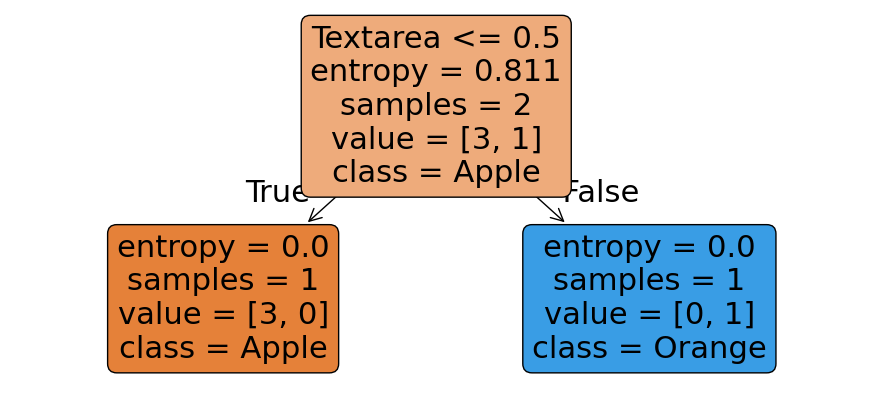

In [23]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
choose_tree=model.estimators_[0]
plt.figure(figsize=(11,5))

plot_tree(choose_tree,
         feature_names=['Weight','Texture','Color'],
         class_names=['Apple','Orange'],
         filled=True,
         rounded=True)
plt.show()

# Support Vactor Machine

In [3]:
import pandas as pd
df=pd.read_csv('diabetes.csv')
x=df.iloc[:,0:8]
y=df['Outcome']
print(x.shape)
print(y.shape)
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)
df.head()

(768, 8)
(768,)
(614, 8)
(154, 8)
(614,)
(154,)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [9]:
from sklearn.svm import SVC
classifier = SVC(kernel='rbf',C=1.0,random_state=0)
model=classifier.fit(x_train,y_train)
prediction=model.predict(x_test)
#print(prediction)

In [8]:
from sklearn.metrics import confusion_matrix,accuracy_score
cm=confusion_matrix(y_test,prediction)
print(cm)
print()
print("Accuracy score: ",accuracy_score(y_test,prediction))

[[93  6]
 [27 28]]

Accuracy score:  0.7857142857142857


In [11]:
SVC??

Init signature:
SVC(
    *,
    C=1.0,
    kernel='rbf',
    degree=3,
    gamma='scale',
    coef0=0.0,
    shrinking=True,
    probability=False,
    tol=0.001,
    cache_size=200,
    class_weight=None,
    verbose=False,
    max_iter=-1,
    decision_function_shape='ovr',
    break_ties=False,
    random_state=None,
)
Source:        
class SVC(BaseSVC):
    """C-Support Vector Classification.

    The implementation is based on libsvm. The fit time scales at least
    quadratically with the number of samples and may be impractical
    beyond tens of thousands of samples. For large datasets
    consider using :class:`~sklearn.svm.LinearSVC` or
    :class:`~sklearn.linear_model.SGDClassifier` instead, possibly after a
    :class:`~sklearn.kernel_approximation.Nystroem` transformer or
    other :ref:`kernel_approximation`.

    The multiclass support is handled according to a one-vs-one scheme.

    For details on the precise mathematical formulation of the provided
    kernel functio